# Example of Gradient Based Approach (Johansen)

## Import Dependencies

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

sys.path.insert(0, os.path.abspath("../../src"))  # adjust path as needed
import soil_heat 

## Define Constants

In [13]:
# SoilVUE depths
DEPTHS_CM = np.array([5, 10, 20, 30, 40, 50, 60], dtype=float)
DEPTHS_M = DEPTHS_CM / 100.0

# Layer boundaries: midpoints between sensors, with surface and bottom extension
LAYER_BOUNDS_CM = np.array([0, 7.5, 15, 25, 35, 45, 55, 65], dtype=float)
LAYER_THICK_M = np.diff(LAYER_BOUNDS_CM) / 100.0

# Thermal constants
CV_W = 4.186e6    # water volumetric heat capacity (J/(m³·K))
CV_S = 2.0e6      # mineral solids (J/(m³·K))
CV_A = 1250.0     # air (J/(m³·K))
CV_ORG = 2.5e6    # organic matter (J/(m³·K))
LAMBDA_W = 0.594  # water thermal conductivity (W/(m·K))
LAMBDA_S = 2.5    # quartz (W/(m·K))

# Default soil assumptions
POROSITY = 0.5
F_QUARTZ = 0.5
F_ORGANIC = 0.02
DT_SEC = 3600.0   # hourly data

# Assumed heat flux plate depth (cm) for storage comparison
PLATE_DEPTH_CM = 5.0

## Define Functions

In [14]:
def compute_metrics(measured, estimated):
    mask = np.isfinite(measured) & np.isfinite(estimated)
    m, e = measured[mask], estimated[mask]
    if len(m) < 10:
        return {"n": 0, "RMSE": np.nan, "MBE": np.nan, "R2": np.nan}
    rmse = np.sqrt(np.mean((e - m) ** 2))
    mbe = np.mean(e - m)
    ss_res = np.sum((e - m) ** 2)
    ss_tot = np.sum((m - np.mean(m)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {"n": int(len(m)), "RMSE": round(rmse, 2), "MBE": round(mbe, 2), "R2": round(r2, 4)}

## Load Data

In [15]:
filepath = "shf.csv"

df = pd.read_csv(filepath, parse_dates=["DATETIME_END"])
df = df.set_index("DATETIME_END").sort_index()

suffixes = ["3_1_1", "3_2_1", "3_3_1", "3_4_1", "3_5_1", "3_6_1", "3_7_1"]
ts_cols = [f"TS_{s}" for s in suffixes]
swc_cols = [f"SWC_{s}" for s in suffixes]

ts = df[ts_cols].copy()
ts.columns = DEPTHS_CM
swc = df[swc_cols].copy()
swc.columns = DEPTHS_CM
swc = swc / 100.0  # percent → fractional

G_meas = df["G_2_1_1"]
SG_meas = df["SG_2_1_1"]

print(f"\nData: {len(df)} hourly records, {ts.index[0]} → {ts.index[-1]}")
print(f"Sensor depths: {DEPTHS_CM.astype(int)} cm")
print(f"Assumed porosity: {POROSITY:.2f}, quartz frac: {F_QUARTZ:.2f}")


Data: 5136 hourly records, 2025-03-01 00:00:00 → 2025-09-30 23:00:00
Sensor depths: [ 5 10 20 30 40 50 60] cm
Assumed porosity: 0.50, quartz frac: 0.50


## Calculate Thermal Properties

In [16]:
# --- Thermal properties ---
print("\n─── Thermal Property Summary (time-mean values) ───")
print(f"{'Depth':>8s}  {'θ (m³/m³)':>10s}  {'Cv (MJ/m³K)':>12s}  {'λ_Joh (W/mK)':>13s}  {'λ_Lu (W/mK)':>12s}")
for d in DEPTHS_CM:
    th = swc[d].mean()
    cv = soil_heat.volumetric_heat_capacity(th) / 1e6
    lj = soil_heat.thermal_conductivity_johansen(th)
    ll = soil_heat.thermal_conductivity_lu2007(th)
    print(f"  {d:5.0f} cm  {th:10.3f}  {cv:12.3f}  {lj:13.3f}  {ll:12.3f}")


─── Thermal Property Summary (time-mean values) ───
   Depth   θ (m³/m³)   Cv (MJ/m³K)   λ_Joh (W/mK)   λ_Lu (W/mK)
      5 cm       0.067         1.453          0.695         0.330
     10 cm       0.040         1.339          0.530         0.307
     20 cm       0.056         1.406          0.636         0.321
     30 cm       0.075         1.484          0.729         0.336
     40 cm       0.142         1.763          0.933         0.389
     50 cm       0.133         1.729          0.914         0.383
     60 cm       0.154         1.815          0.960         0.399


## Run Relevant Methods

In [17]:
# --- Run all methods ---
G_gps20 = soil_heat.gradient_plus_storage(ts, swc, ref_depth_idx=2, lam_model="johansen")

# Storage comparison (shallow layer above plate)
S_plate_est = soil_heat.compute_storage_above_plate(ts, swc, plate_depth_cm=PLATE_DEPTH_CM)

# --- Metrics ---
methods = {
    "Grad@20cm + Storage(0→20)": G_gps20,
}

print("\n─── Method Comparison vs Measured G ───")
print(f"{'Method':<35s}  {'N':>5s}  {'RMSE':>7s}  {'MBE':>7s}  {'R²':>8s}")
metrics_list = []
for name, est in methods.items():
    m = compute_metrics(G_meas.values, est.values)
    metrics_list.append({"Method": name, **m})
    print(f"  {name:<33s}  {m['n']:5d}  {m['RMSE']:7.1f}  {m['MBE']:7.1f}  {m['R2']:8.4f}")

# Storage comparison
print("\n─── Heat Storage Comparison ───")
ms = compute_metrics(SG_meas.values, S_plate_est.values)
print(f"  Storage (0→{PLATE_DEPTH_CM:.0f}cm) vs measured SG:")
print(f"    RMSE={ms['RMSE']:.1f} W/m²  MBE={ms['MBE']:.1f} W/m²  R²={ms['R2']:.4f}")



─── Method Comparison vs Measured G ───
Method                                   N     RMSE      MBE        R²
  Grad@20cm + Storage(0→20)           4871     30.5     -0.9    0.7711

─── Heat Storage Comparison ───
  Storage (0→5cm) vs measured SG:
    RMSE=15.0 W/m²  MBE=1.2 W/m²  R²=0.6049


## Determine sensitivity to soil porosity

In [18]:
# --- Sensitivity ---
print("\n─── Porosity Sensitivity (Method 3a: Grad@20cm + Storage) ───")
for n_test in [0.35, 0.40, 0.42, 0.45, 0.50, 0.55, 0.60, 0.65]:
    dTdt_p = ts.diff() / DT_SEC
    cv_p = soil_heat.volumetric_heat_capacity(swc.values, porosity=n_test)
    S_above_p = np.nansum(cv_p[:, :3] * dTdt_p.values[:, :3] * LAYER_THICK_M[:3], axis=1)
    lam_p = soil_heat.thermal_conductivity_johansen(swc[20.0].values, porosity=n_test)
    G_ref_p = -lam_p * (ts[30.0].values - ts[10.0].values) / 0.2
    G_test = G_ref_p + S_above_p
    mt = compute_metrics(G_meas.values, G_test)
    print(f"  n={n_test:.2f}: RMSE={mt['RMSE']:6.1f}  MBE={mt['MBE']:6.1f}  R²={mt['R2']:.4f}")


─── Porosity Sensitivity (Method 3a: Grad@20cm + Storage) ───
  n=0.35: RMSE=  34.1  MBE=  -0.6  R²=0.7147
  n=0.40: RMSE=  31.4  MBE=  -0.8  R²=0.7580
  n=0.42: RMSE=  30.5  MBE=  -0.9  R²=0.7711
  n=0.45: RMSE=  29.5  MBE=  -1.0  R²=0.7861
  n=0.50: RMSE=  28.6  MBE=  -1.2  R²=0.7997
  n=0.55: RMSE=  28.6  MBE=  -1.3  R²=0.7995
  n=0.60: RMSE=  29.5  MBE=  -1.5  R²=0.7858
  n=0.65: RMSE=  31.3  MBE=  -1.6  R²=0.7594


In [19]:
# --- Diurnal composite ---
hourly = pd.DataFrame({
    "hour": G_meas.index.hour,
    "Measured": G_meas.values,
    "Grad+Stor@20": G_gps20.values,
})
diurnal = hourly.groupby("hour").mean()

# --- Energy balance context ---
G_nr_daily = pd.DataFrame({"Rn": df["NETRAD_1_1_1"], "G": G_meas}).resample("D").mean()
mask_nr = G_nr_daily["Rn"].abs() > 10
ratio = (G_nr_daily["G"][mask_nr] / G_nr_daily["Rn"][mask_nr]).mean()
print(f"\n─── Energy Balance Context ───")
print(f"  Mean daily G/Rn: {ratio:.3f}")
print(f"  (Expected near zero for daily averages; typical daytime G/Rn ≈ 0.05–0.15)")


─── Energy Balance Context ───
  Mean daily G/Rn: 0.005
  (Expected near zero for daily averages; typical daytime G/Rn ≈ 0.05–0.15)


# Plots

## Plot 1

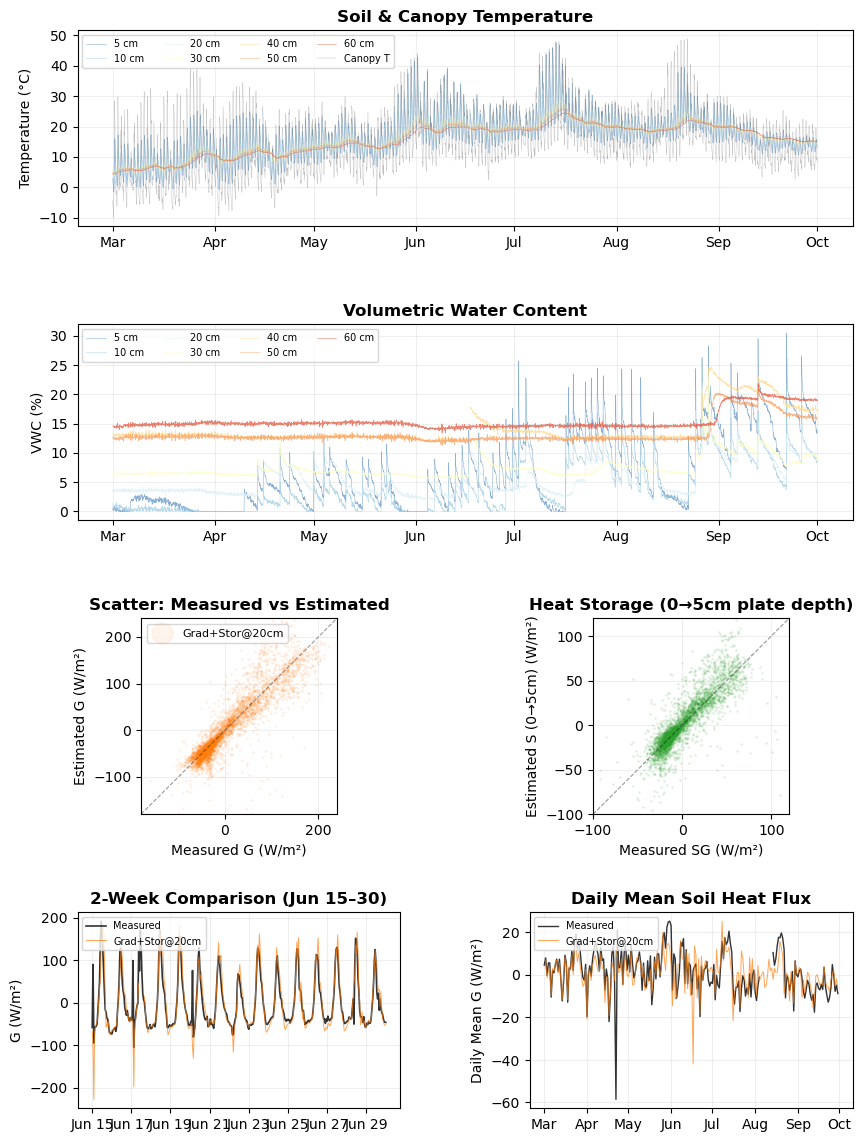

In [20]:
fig = plt.figure(figsize=(10, 14))
gs = GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.4)

# 1a. Temperature time series
ax1 = fig.add_subplot(gs[0, :])
colors_t = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, len(DEPTHS_CM)))
for i, d in enumerate(DEPTHS_CM):
    ax1.plot(ts.index, ts[d], lw=0.4, alpha=0.7, color=colors_t[i], label=f"{d:.0f} cm")
ax1.plot(df.index, df["T_CANOPY_1_1_1"], lw=0.3, alpha=0.5, color="gray", label="Canopy T")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(ncol=4, fontsize=7, loc="upper left")
ax1.set_title("Soil & Canopy Temperature", fontweight="bold")
ax1.grid(True, alpha=0.2)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# 1b. VWC time series
ax2 = fig.add_subplot(gs[1, :])
for i, d in enumerate(DEPTHS_CM):
    ax2.plot(swc.index, swc[d] * 100, lw=0.4, alpha=0.7, color=colors_t[i], label=f"{d:.0f} cm")
ax2.set_ylabel("VWC (%)")
ax2.legend(ncol=4, fontsize=7, loc="upper left")
ax2.set_title("Volumetric Water Content", fontweight="bold")
ax2.grid(True, alpha=0.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# 1c. Scatter: Measured vs Estimated G (best methods)
ax3 = fig.add_subplot(gs[2, 0])
mask_s2 = np.isfinite(G_meas.values) & np.isfinite(G_gps20.values)
ax3.scatter(G_meas.values[mask_s2], G_gps20.values[mask_s2], s=1, alpha=0.08, c="C1", label="Grad+Stor@20cm")
lims = [-180, 240]
ax3.plot(lims, lims, "k--", lw=0.8, alpha=0.4)
ax3.set_xlim(lims); ax3.set_ylim(lims)
ax3.set_xlabel("Measured G (W/m²)"); ax3.set_ylabel("Estimated G (W/m²)")
ax3.legend(fontsize=8, markerscale=15, loc="upper left")
ax3.set_title("Scatter: Measured vs Estimated", fontweight="bold")
ax3.grid(True, alpha=0.2)
ax3.set_aspect("equal")

# 1d. Storage scatter (plate-depth comparison)
ax4 = fig.add_subplot(gs[2, 1])
mask_sp = np.isfinite(SG_meas.values) & np.isfinite(S_plate_est.values)
ax4.scatter(SG_meas.values[mask_sp], S_plate_est.values[mask_sp], s=1, alpha=0.1, c="C2")
slims = [-100, 120]
ax4.plot(slims, slims, "k--", lw=0.8, alpha=0.4)
ax4.set_xlim(slims); ax4.set_ylim(slims)
ax4.set_xlabel("Measured SG (W/m²)"); ax4.set_ylabel(f"Estimated S (0→{PLATE_DEPTH_CM:.0f}cm) (W/m²)")
ax4.set_title(f"Heat Storage (0→{PLATE_DEPTH_CM:.0f}cm plate depth)", fontweight="bold")
ax4.grid(True, alpha=0.2)
ax4.set_aspect("equal")

# 1e. 2-week comparison (Jun 15-30)
ax5 = fig.add_subplot(gs[3, 0])
w = (ts.index >= "2025-06-15") & (ts.index <= "2025-06-30")
ax5.plot(G_meas.index[w], G_meas.values[w], "k-", lw=1.2, alpha=0.8, label="Measured")
ax5.plot(G_gps20.index[w], G_gps20.values[w], "-", lw=0.7, alpha=0.7, color="C1", label="Grad+Stor@20cm")
ax5.set_ylabel("G (W/m²)")
ax5.legend(fontsize=7, loc="upper left")
ax5.set_title("2-Week Comparison (Jun 15–30)", fontweight="bold")
ax5.grid(True, alpha=0.2)
ax5.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# 1f. Daily mean G
ax6 = fig.add_subplot(gs[3, 1])
G_daily = pd.DataFrame({"Measured": G_meas, 
                            "Grad+Stor@20cm": G_gps20}).resample("D").mean()
ax6.plot(G_daily.index, G_daily["Measured"], "k-", lw=1, alpha=0.8, label="Measured")
ax6.plot(G_daily.index, G_daily["Grad+Stor@20cm"], "-", lw=0.7, color="C1", alpha=0.7, label="Grad+Stor@20cm")
ax6.set_ylabel("Daily Mean G (W/m²)")
ax6.legend(fontsize=7, loc="upper left")
ax6.set_title("Daily Mean Soil Heat Flux", fontweight="bold")
ax6.grid(True, alpha=0.2)
ax6.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.show()

## Plot 2

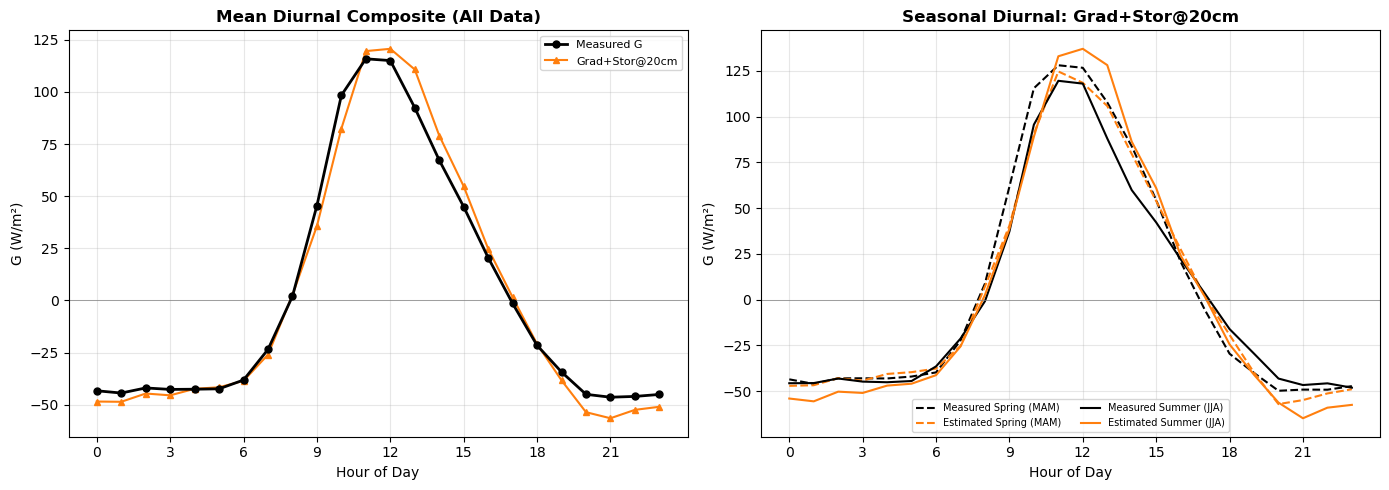

In [21]:
# --- Figure 2: Diurnal Composite ---
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 5))

ax2a.plot(diurnal.index, diurnal["Measured"], "k-o", lw=2, ms=5, label="Measured G", zorder=5)
ax2a.plot(diurnal.index, diurnal["Grad+Stor@20"], "-^", lw=1.5, ms=4, color="C1", label="Grad+Stor@20cm")

ax2a.axhline(0, color="gray", lw=0.5)
ax2a.set_xlabel("Hour of Day")
ax2a.set_ylabel("G (W/m²)")
ax2a.set_title("Mean Diurnal Composite (All Data)", fontweight="bold")
ax2a.legend(fontsize=8)
ax2a.grid(True, alpha=0.3)
ax2a.set_xticks(range(0, 24, 3))

# Seasonal diurnal comparison (spring vs summer)
spring = (G_meas.index.month >= 3) & (G_meas.index.month <= 5)
summer = (G_meas.index.month >= 6) & (G_meas.index.month <= 8)

for season_mask, label, ls in [(spring, "Spring (MAM)", "--"), (summer, "Summer (JJA)", "-")]:
    hourly_s = pd.DataFrame({
        "hour": G_meas.index[season_mask].hour,
        "Measured": G_meas.values[season_mask],
        "Estimated": G_gps20.values[season_mask],
    })
    diurnal_s = hourly_s.groupby("hour").mean()
    ax2b.plot(diurnal_s.index, diurnal_s["Measured"], f"k{ls}", lw=1.5, label=f"Measured {label}")
    ax2b.plot(diurnal_s.index, diurnal_s["Estimated"], f"C1{ls}", lw=1.5, label=f"Estimated {label}")

ax2b.axhline(0, color="gray", lw=0.5)
ax2b.set_xlabel("Hour of Day")
ax2b.set_ylabel("G (W/m²)")
ax2b.set_title("Seasonal Diurnal: Grad+Stor@20cm", fontweight="bold")
ax2b.legend(fontsize=7, ncol=2)
ax2b.grid(True, alpha=0.3)
ax2b.set_xticks(range(0, 24, 3))

plt.tight_layout()

## Plot 3

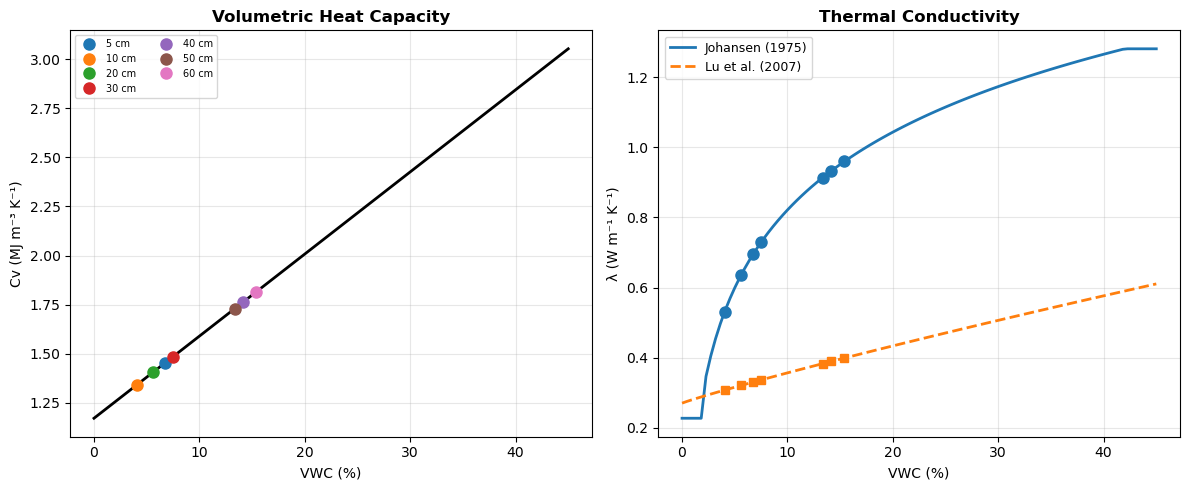

In [22]:
# --- Figure 3: Thermal property dependence on VWC ---
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(12, 5))

theta_range = np.linspace(0, 0.45, 100)
cv_range = soil_heat.volumetric_heat_capacity(theta_range) / 1e6
ax3a.plot(theta_range * 100, cv_range, "k-", lw=2)
for d in DEPTHS_CM:
    th_m = swc[d].mean()
    cv_m = soil_heat.volumetric_heat_capacity(th_m) / 1e6
    ax3a.plot(th_m * 100, cv_m, "o", ms=8, label=f"{d:.0f} cm")
ax3a.set_xlabel("VWC (%)")
ax3a.set_ylabel("Cv (MJ m⁻³ K⁻¹)")
ax3a.set_title("Volumetric Heat Capacity", fontweight="bold")
ax3a.legend(fontsize=7, ncol=2)
ax3a.grid(True, alpha=0.3)

lam_j = soil_heat.thermal_conductivity_johansen(theta_range)
lam_l = soil_heat.thermal_conductivity_lu2007(theta_range)
ax3b.plot(theta_range * 100, lam_j, "-", lw=2, label="Johansen (1975)")
ax3b.plot(theta_range * 100, lam_l, "--", lw=2, label="Lu et al. (2007)")
for d in DEPTHS_CM:
    th_m = swc[d].mean()
    ax3b.plot(th_m * 100, soil_heat.thermal_conductivity_johansen(th_m), "o", ms=8, color="C0")
    ax3b.plot(th_m * 100, soil_heat.thermal_conductivity_lu2007(th_m), "s", ms=6, color="C1")
ax3b.set_xlabel("VWC (%)")
ax3b.set_ylabel("λ (W m⁻¹ K⁻¹)")
ax3b.set_title("Thermal Conductivity", fontweight="bold")
ax3b.legend(fontsize=9)
ax3b.grid(True, alpha=0.3)

plt.tight_layout()


